<a href="https://colab.research.google.com/github/MrMortanya/Astronomy/blob/main/Astronomy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data Cleaning & Setup

In [7]:
url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/SB%20Close%20Approaches/earth_close_approaches_50yr.csv"

df = pd.read_csv(url)

# 1. First I'll begin by cleaning the dataset.

# Clean columns
df.columns = df.columns.str.strip()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert the date column to datetime
df["cd"] = pd.to_datetime(df["cd"])

# Create a Year column
df["Year"] = df["cd"].dt.year

# Keep the needed columns
df = df[["des", "Year", "cd", "dist", "v_rel"]]

# Remove rows with missing values
df.dropna(subset=["dist", "v_rel"], inplace=True)

# Reset the row numbers
df.reset_index(drop=True, inplace=True)

df.head()

closest_by_year = df.loc[df.groupby("Year")["dist"].idxmin()]

closest_by_year



,des,Year,cd,dist,v_rel
2345,2025 XR,1976,1976-12-05 05:49:00,0.000475,18.468097
4136,2022 QX4,1977,1977-09-05 01:47:00,0.000861,9.431373
7354,2025 XZ4,1978,1978-12-13 15:48:00,0.001564,20.251605
9020,2014 WX202,1979,1979-09-02 00:16:00,0.002237,1.793308
10788,2025 JE,1980,1980-05-08 13:34:00,0.000617,6.569595
13692,2018 AB12,1981,1981-07-22 08:32:00,0.003438,8.771882
16624,2025 TQ2,1982,1982-10-02 23:22:00,0.000815,12.319746
17624,2022 DJ1,1983,1983-02-24 07:39:00,0.003339,4.403989
19798,2016 TB57,1984,1984-01-10 00:58:00,0.001971,2.789490
24306,2019 VC37,1985,1985-11-01 04:21:00,0.001696,5.890980


# Research Question:
During the 50-year dataset, which years had the closest and fastest asteroid approach Earth.


Year
1976    0.000475
1977    0.000861
1978    0.001564
1979    0.002237
1980    0.000617
1981    0.003438
1982    0.000815
1983    0.003339
1984    0.001971
1985    0.001696
1986    0.002423
1987    0.002561
1988    0.002455
1989    0.001994
1990    0.001376
1991    0.001124
1992    0.000418
1993    0.000997
1994    0.000704
1995    0.002896
1996    0.002308
1997    0.005186
1998    0.003376
1999    0.002095
2000    0.001796
2001    0.000803
2002    0.000787
2003    0.000563
2004    0.000086
2005    0.000560
2006    0.000785
2007    0.000466
2008    0.000084
2009    0.000137
2010    0.000260
2011    0.000079
2012    0.000139
2013    0.000181
2014    0.000134
2015    0.000178
2016    0.000096
2017    0.000109
2018    0.000091
2019    0.000084
2020    0.000045
2021    0.000063
2022    0.000099
2023    0.000067
2024    0.000052
2025    0.000044
2026    0.000014
Name: dist, dtype: float64


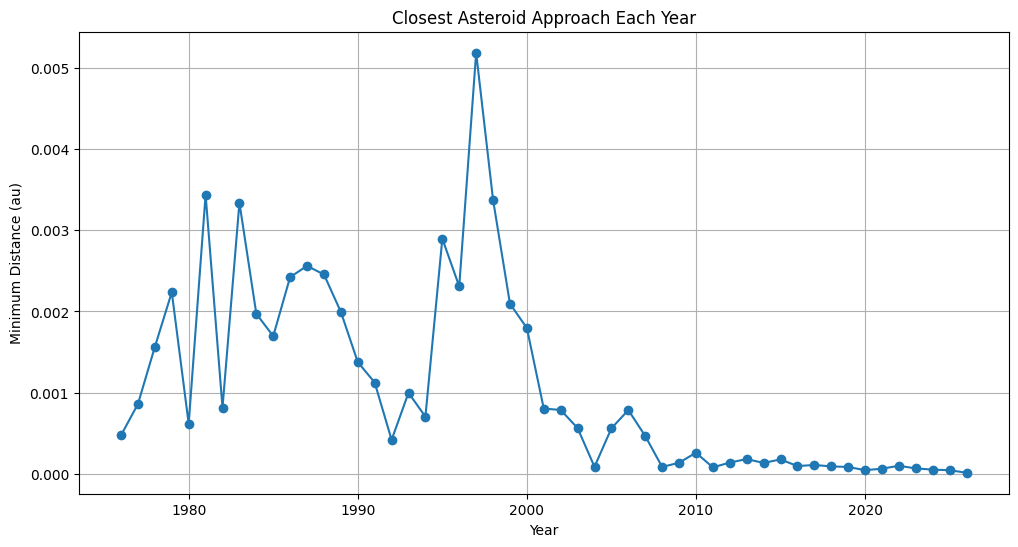

In [11]:
# 2. I'll make a line plot to demonstrate how close an asteroid was to hitting, the year being the x-axis and the distance being the y-axis.

df["cd"] = pd.to_datetime(df["cd"])
df["Year"] = df["cd"].dt.year

closest_each_year = df.groupby("Year")["dist"].min()

print(closest_each_year)


plt.figure(figsize=(12,6))

plt.plot(closest_each_year.index,
         closest_each_year.values,
         marker='o')

plt.title("Closest Asteroid Approach Each Year")
plt.xlabel("Year")
plt.ylabel("Minimum Distance (au)")
plt.grid(True)

plt.show()

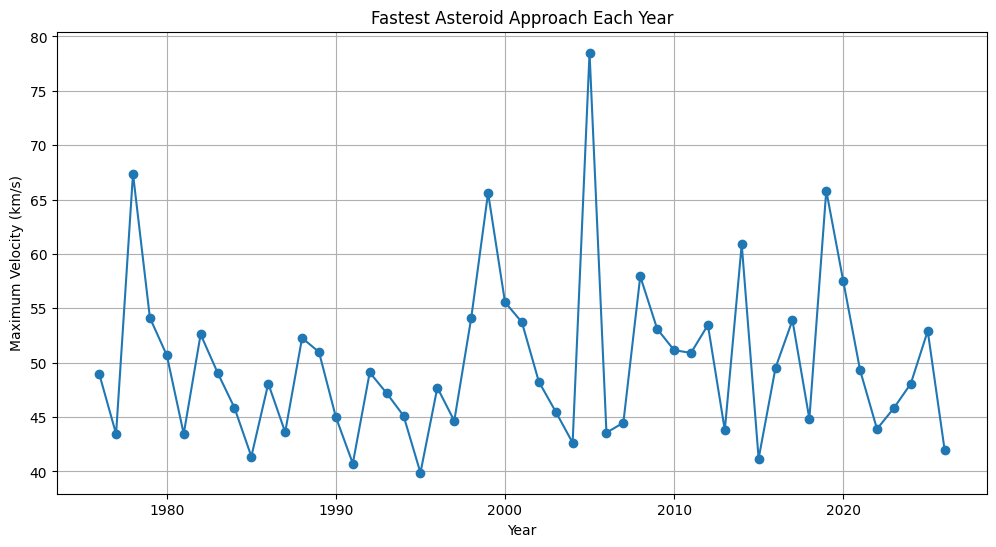

        Year        des                  cd      dist      v_rel
185888  2026   2026 JN4 2026-05-15 13:44:00  0.000014  23.192931
182599  2025  2025 UC11 2025-10-30 12:11:00  0.000044  11.364929
149619  2020   2020 VT4 2020-11-13 17:21:00  0.000045  13.427120
181989  2025    2025 TF 2025-10-01 00:49:00  0.000045  20.876114
177167  2024    2024 XA 2024-12-01 09:46:00  0.000052  13.565976
173843  2024   2024 LH1 2024-06-06 14:02:00  0.000054  17.404073
176529  2024   2024 UG9 2024-10-30 12:42:00  0.000059  20.304681
147716  2020    2020 QG 2020-08-16 04:09:00  0.000062  12.330867
156019  2021   2021 UA1 2021-10-25 03:07:00  0.000063  15.835007
178130  2025   2025 BP6 2025-01-26 01:10:00  0.000065  21.046976


In [12]:
# 3. Similarly to the closest by year, I'll create a line plot demonstrating the speed of the asteroids against the year.

fastest_each_year = df.groupby("Year")["v_rel"].max()

plt.figure(figsize=(12,6))

plt.plot(fastest_each_year.index,
         fastest_each_year.values,
         marker='o')

plt.title("Fastest Asteroid Approach Each Year")
plt.xlabel("Year")
plt.ylabel("Maximum Velocity (km/s)")
plt.grid(True)


plt.show()

closest = df.nsmallest(10, "dist")

print(closest[["Year", "des", "cd", "dist", "v_rel"]])
